# 01 · 探索資料：我怎麼知道資料是「好」的？

「好資料」不是憑感覺，是把它拆成**可計算的指標**。這本 notebook 把每個維度算出來、畫出來，讓你**有數字、有依據**地判斷。

| 維度 | 指標 | 怎麼算 | 好的樣子 |
|---|---|---|---|
| 量 | total_chars / tokens | 數總量 | 小型 LM ≥ 1M 字元 |
| 多元性 | 字元熵 entropy | Shannon 公式 | 英文約 4–4.5 bits |
| 重複度 | 壓縮比 compression | gzip 後/原始 | 約 0.3–0.45（越小越重複）|
| 乾淨度 | quality / dedup 砍量 | pipeline 報表 | 過濾有作用、重複率不高 |
| 形狀 | 文件長度分布 | 直方圖 | 別一堆超短文件 |

> 邏輯都在 `src/data/stats.py`（已測試）；這裡只負責「互動呈現」。
> 先在終端機跑過 `make data-demo`（或 `make data` 用 shakespeare）產生 artifacts。

In [1]:
import sys, json
from pathlib import Path
from collections import Counter

# 讓 notebook 找得到專案的 src/（notebooks/ 在專案根目錄下一層）
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
ART = ROOT / 'artifacts'
assert (ART / 'meta.json').exists(), '找不到 artifacts，請先在終端機跑 `make data-demo`'

from src.data import stats
m = stats.print_report(ART)   # 文字版總表 + 健康判讀

資料品質報表
  文件：13 -> 8    字元：971    token：971
  vocab_size：81    字元熵：4.701 bits    壓縮比：0.647
--------------------------------------------------------
  ❌ 資料量(字元)                 971   小型 LM 建議 ≥ 1M 字元；太少只會過擬合背答案
  ✅ 字元熵(bits/char)         4.70   英文約 4–4.5；太低代表重複/退化
  ✅ 壓縮比                    0.65   越小越重複；自然語言約 0.3–0.45
  ✅ 重複率                    0.15   去重砍掉的比例；偏高代表來源大量轉貼


## 維度 1–2：量 與 多元性

- **量**：`total_chars` 太少，模型只會「背」訓練資料（過擬合），學不到語言結構。示範語料故意很小，所以上面會看到 ❌——這是正常的，提醒你正式訓練要換大語料。
- **字元熵**：衡量用字多不多元。全是同一個字 → 0 bits；分布越平均越高。太低通常代表重複或退化文本。
- **壓縮比**：最便宜的「重複度」代理。文字越重複越好壓，比值越小。

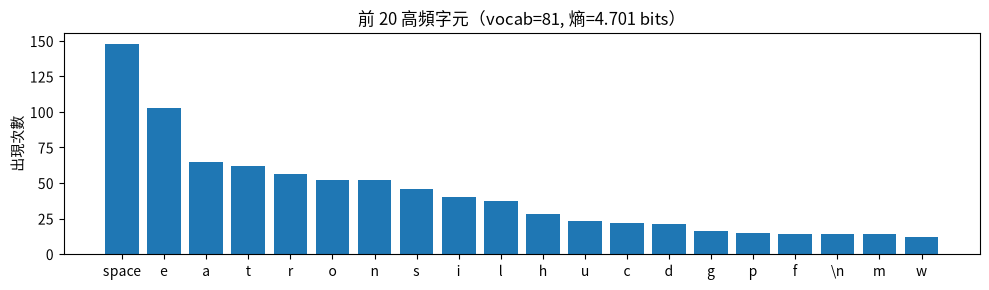

解讀：若少數字元就吃掉絕大多數比例，熵會偏低 → 資料偏重複。


In [2]:
import matplotlib.pyplot as plt

corpus = (ART / 'clean_corpus.txt').read_text(encoding='utf-8')
top = stats.char_frequencies(corpus, 20)
labels = [repr(c)[1:-1] if c.strip() else ('\\n' if c=='\n' else 'space') for c, _ in top]
counts = [n for _, n in top]

plt.figure(figsize=(10, 3))
plt.bar(range(len(top)), counts)
plt.xticks(range(len(top)), labels)
plt.title(f'前 20 高頻字元（vocab={m["vocab_size"]}, 熵={m["char_entropy"]} bits）')
plt.ylabel('出現次數')
plt.tight_layout(); plt.show()
print('解讀：若少數字元就吃掉絕大多數比例，熵會偏低 → 資料偏重複。')

## 維度 3：文件長度分布

重新載入原始文件、跑同一套清洗，看每篇有多長。一堆超短文件代表來源品質可疑（標題、空殼頁）。

長度摘要： {'count': 13, 'min': 2, 'max': 536, 'mean': 140.9, 'median': 77}


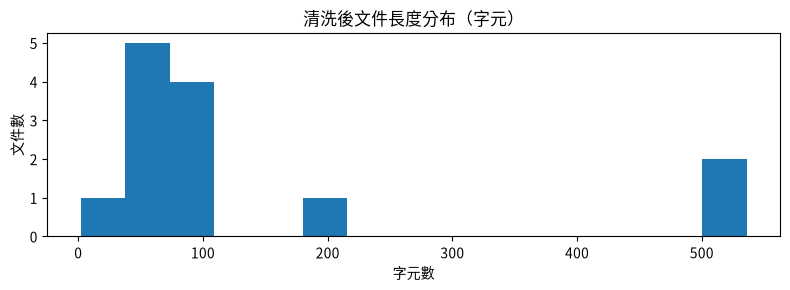

In [3]:
from src.data.sources import load_documents
from src.data import clean as C

# 用跟 pipeline 同一套清洗，算清洗後的長度
raw = load_documents(ROOT / 'data' / 'raw' / 'demo')
lengths = [len(C.normalize_text(d.text)) for d in raw]
print('長度摘要：', stats.doc_length_stats(lengths))

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=15)
plt.title('清洗後文件長度分布（字元）')
plt.xlabel('字元數'); plt.ylabel('文件數')
plt.tight_layout(); plt.show()

## 維度 4：乾淨度 / 重複率（pipeline 每一關砍了什麼）

資料品質也看「進來時有多髒」——過濾與去重砍掉的比例。砍很多 = 來源髒；砍 0 可能是過濾太鬆。

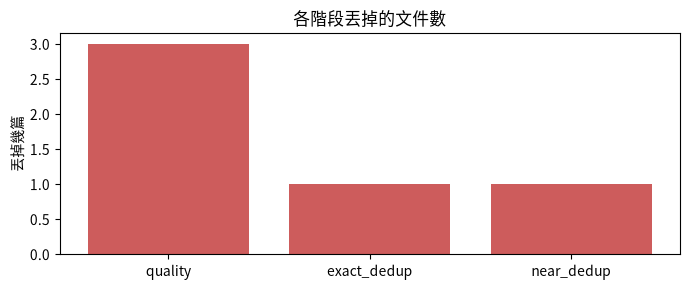

重複率=0.154  品質過濾率=0.231


In [4]:
report = json.loads((ART / 'data_report.json').read_text())
stage_names = [s['stage'] for s in report['stages']]
dropped = [s['dropped'] for s in report['stages']]

plt.figure(figsize=(7, 3))
plt.bar(stage_names, dropped, color='indianred')
plt.title('各階段丟掉的文件數')
plt.ylabel('丟掉幾篇')
plt.tight_layout(); plt.show()
print(f"重複率={m['dup_rate']}  品質過濾率={m['junk_rate']}")

## 怎麼用這份判斷 + 下一步

1. **量**：示範語料太小（❌）。換 `make data`（tiny-shakespeare ~1MB）或你自己的文本，再重跑這本 notebook，數字才有意義。
2. **多元性**：熵太低 / 壓縮比太小 → 資料太重複，要找更多樣的來源。
3. **重複率**：偏高 → 來源大量轉貼，dedup 救得了一部分，但最好換來源。
4. 探索到這裡若發現某個清洗規則該調，去改 `src/data/clean.py`，跑 `make verify` 確認沒壞——**notebook 探索 → 固化進 .py → test/playbook 守住**。

> 想換語料：`make data` 後把這本 notebook 從頭跑一次即可。